In [2]:
file_name = r"C:\Users\User\Downloads\cta0003.wav"

In [3]:
from scipy.io import wavfile
import numpy as np
import matplotlib.pyplot as plt

In [4]:
fs, data = wavfile.read(file_name)

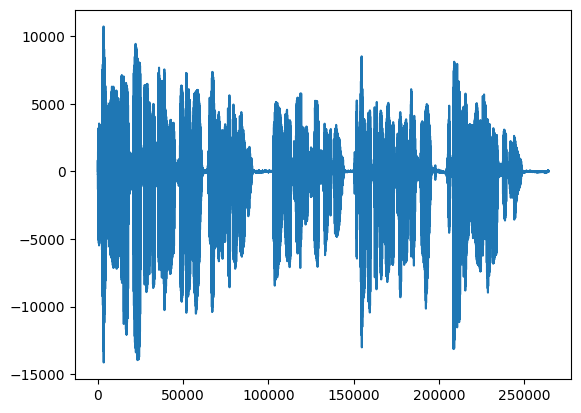

In [5]:
plt.plot(data)

In [6]:
rectified = np.where(data > 0, data, 0)

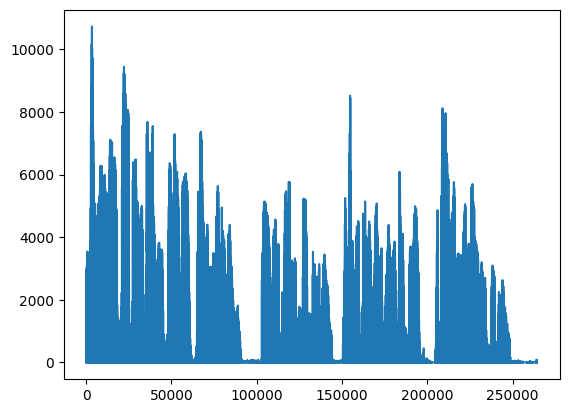

In [7]:
plt.plot(rectified)

In [8]:
from scipy.signal import butter, filtfilt, resample

In [9]:
nyq = fs / 2
b, a = butter(4, 16/nyq, btype="low")

filtered = filtfilt(b, a, rectified)

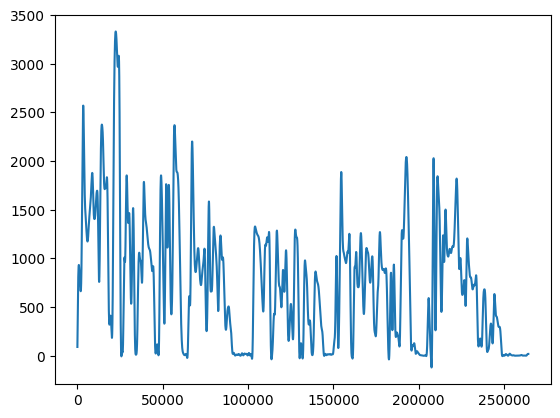

In [10]:
plt.plot(filtered)

In [11]:
target_fs = 100

num_samples = len(filtered) * target_fs // fs

resampled = resample(filtered, num_samples)

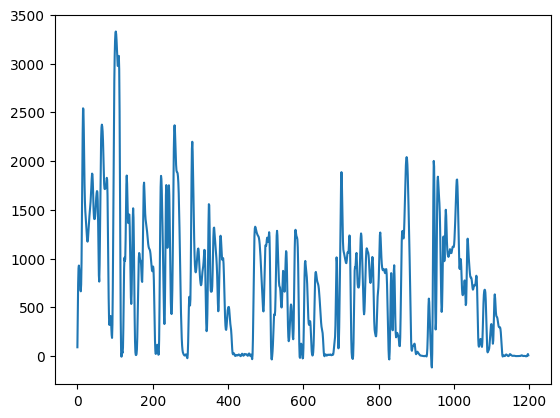

In [12]:
plt.plot(resampled)

In [13]:
window = 1
overlap = 0.75

In [14]:
window_size = int(window * target_fs)
overlap_size = int(overlap * target_fs)

len(resampled), overlap_size

(1198, 75)

In [15]:
enrate = []
times = []

In [16]:
for start in range(0, len(resampled) - window_size + 1, overlap_size):
    window_data = resampled[start: start + window_size]

    print(start, start + window_size)

    window_data_hamming = window_data * np.hamming(window_size)

    fft_res = np.abs(np.fft.rfft(window_data_hamming))

    indices = np.arange(window_size // 2 + 1)

    power = np.sum(fft_res**2)
    spectral_moment = np.sum(indices * fft_res**2) / power

    enrate.append(spectral_moment)
    times.append((start + window_size / 2) / target_fs)

0 100
75 175
150 250
225 325
300 400
375 475
450 550
525 625
600 700
675 775
750 850
825 925
900 1000
975 1075
1050 1150


In [17]:
times, enrate

([0.5,
  1.25,
  2.0,
  2.75,
  3.5,
  4.25,
  5.0,
  5.75,
  6.5,
  7.25,
  8.0,
  8.75,
  9.5,
  10.25,
  11.0],
 [0.36118236608549165,
  0.9867850546092739,
  0.6689294214678088,
  0.8446949143932623,
  0.6069789811769554,
  0.8633444783079773,
  0.635925413107367,
  1.1479199135595224,
  0.994739356449223,
  0.7494781840023014,
  0.5494680421156565,
  0.9562126504215271,
  1.584218597833885,
  0.36826711987933064,
  1.1438039526851813])

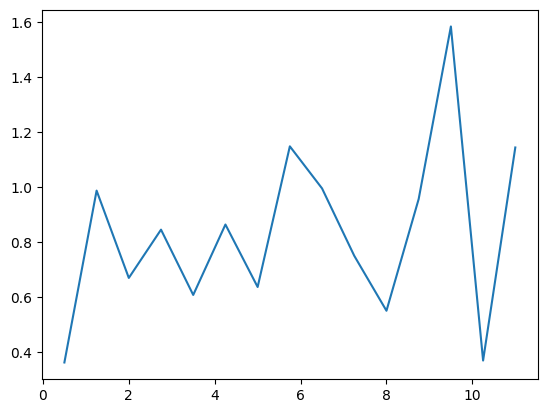

In [18]:
plt.plot(times, enrate)